# 🛒 IronKaggle: Sales Prediction Analysis

## 📁 Project Overview
This notebook contains a comprehensive analysis and machine learning pipeline for predicting store sales. The goal is to identify key factors influencing sales and build a reliable predictive model.


### 🗺️ Table of Contents
1. [Environment Setup](#environment-setup)
2. [Data Acquisition](#data-acquisition)
3. [Data Preprocessing & Cleaning](#data-preprocessing-&-cleaning)
4. [Exploratory Data Analysis (EDA)](#exploratory-data-analysis-(eda))
5. [Feature Engineering & Selection](#feature-engineering-&-selection)
6. [Model Building & Training](#model-building-&-training)
7. [Model Evaluation](#model-evaluation)
8. [Conclusions & Insights](#conclusions-&-insights)


## 🛠️ 1. Environment Setup
Configuring the environment and importing essential libraries.

In [1]:
# Standard Library Imports
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt

# Machine Learning Imports
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialization
le = LabelEncoder()


In [2]:
def evaluate_model(model, X_train, X_test, y_train, y_test, experiment_name):
    """
    Encapsulates the training and evaluation logic for a single model.
    Expects pre-split data to maintain flexibility and global access.
    """
    # Train model
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    print(f"{experiment_name} - RMSE: {rmse:.2f}, R2 Score: {r2:.4f}")
    
    # Visualization: Predictions vs Real Values
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, alpha=0.5, color="blue", s=40, label="Predictions")
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             color="red", linestyle="--", linewidth=2, label="Perfect Line (y=x)")
    plt.xlabel("Actual Sales", fontsize=12)
    plt.ylabel("Predicted Sales", fontsize=12)
    plt.title(f"{experiment_name}: Predicted vs Actual", fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
    
    return model, y_pred

def plot_feature_importance(model, feature_names, title="Feature Importance"):
    """
    Plots the relative importance of features for a trained tree-based model.
    """
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    plt.figure(figsize=(12, 8))
    plt.title(title, fontsize=14)
    plt.bar(range(len(feature_names)), importances[indices], align="center")
    plt.xticks(range(len(feature_names)), [feature_names[i] for i in indices], rotation=90)
    plt.xlabel("Variables", fontsize=12)
    plt.ylabel("Relative Importance", fontsize=12)
    plt.tight_layout()
    plt.show()


## 🧹 3. Data Preprocessing & Cleaning
Refining the dataset for analysis and modeling.

In [3]:
def perform_data_cleanup(df):
    """
    Performs comprehensive data cleaning and preparation.
    - Creates a copy to avoid SettingWithCopyWarning
    - Parsons 'date' and sorts chronologically
    - Filters for only open store records
    - Encodes 'state_holiday' categorical variable
    """
    df_clean = df.copy()
    
    # Convert 'date' to datetime objects and sort chronologically
    df_clean['date'] = pd.to_datetime(df_clean['date'], format='%Y-%m-%d')
    df_clean = df_clean.sort_values(['date'])
    
    # Filter records to include only days when the store was open
    df_clean = df_clean[df_clean['open'] == 1]
    
    # Encode categorical 'state_holiday' labels into numerical values
    df_clean['state_holiday'] = le.fit_transform(df_clean['state_holiday'])
    
    return df_clean


In [4]:
df = pd.read_csv('https://raw.githubusercontent.com/ashishsantikari/lab-functions-en/refs/heads/master/sales.csv')

display(df.head())

# Apply the unified cleaning function
df_filtered = perform_data_cleanup(df)

# Initial verification of the cleaned dataset
display(df_filtered.head())
print(f"Dataset shape after filtering: {df_filtered.shape}")


,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,425390,366,4,2013-04-18,517,1,0,0,0,4422
1,291687,394,6,2015-04-11,694,1,0,0,0,8297
2,411278,807,4,2013-08-29,970,1,1,0,0,9729
3,664714,802,2,2013-05-28,473,1,1,0,0,6513
4,540835,726,4,2013-10-10,1068,1,1,0,0,10882


,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
392388,338008,335,2,2013-01-01,482,1,0,1,1,2401
482306,13557,948,2,2013-01-01,1039,1,0,1,1,4491
222078,253110,423,2,2013-01-01,1751,1,0,1,1,9643
545183,512628,530,2,2013-01-01,532,1,0,1,1,2907
147155,277247,274,2,2013-01-01,729,1,0,1,1,3102


Dataset shape after filtering: (532016, 10)


## 📈 4. Exploratory Data Analysis (EDA)
Analyzing distributions, statistics, and outliers in the data.

In [5]:
# Generate summary statistics for numerical columns in the cleaned dataset
df_filtered.describe()


,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
count,532016.000000,532016.000000,532016.000000,532016,532016.000000,532016.0,532016.000000,532016.000000,532016.000000,532016.000000
mean,355998.345674,558.050115,3.523479,2014-04-11 01:51:15.336079,762.960407,1.0,0.446520,0.001460,0.193229,6959.251679
min,0.000000,1.000000,1.000000,2013-01-01 00:00:00,0.000000,1.0,0.000000,0.000000,0.000000,0.000000
25%,178080.750000,280.000000,2.000000,2013-08-17 00:00:00,519.000000,1.0,0.000000,0.000000,0.000000,4861.000000
50%,355963.500000,558.000000,3.000000,2014-03-31 00:00:00,676.000000,1.0,0.000000,0.000000,0.000000,6372.000000
75%,533943.500000,836.000000,5.000000,2014-12-10 00:00:00,893.000000,1.0,1.000000,0.000000,0.000000,8365.000000
max,712044.000000,1115.000000,7.000000,2015-07-31 00:00:00,5458.000000,1.0,1.000000,3.000000,1.000000,41551.000000
std,205568.449180,321.613167,1.723849,NaN,400.736508,0.0,0.497132,0.048817,0.394832,3105.241710


## 🤖 5. Model Building & Training
Splitting the data and training a predictive model.

Random Forest (Baseline) - RMSE: 1719.34, R2 Score: 0.6943


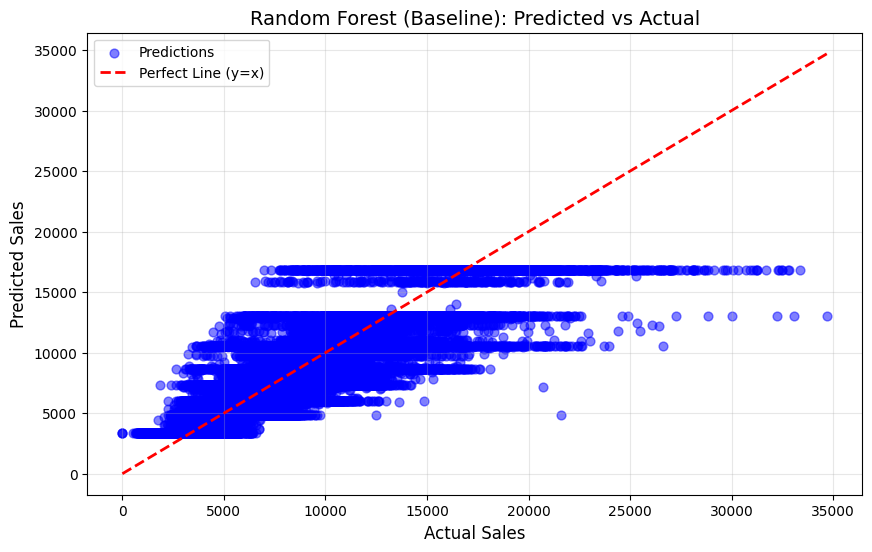

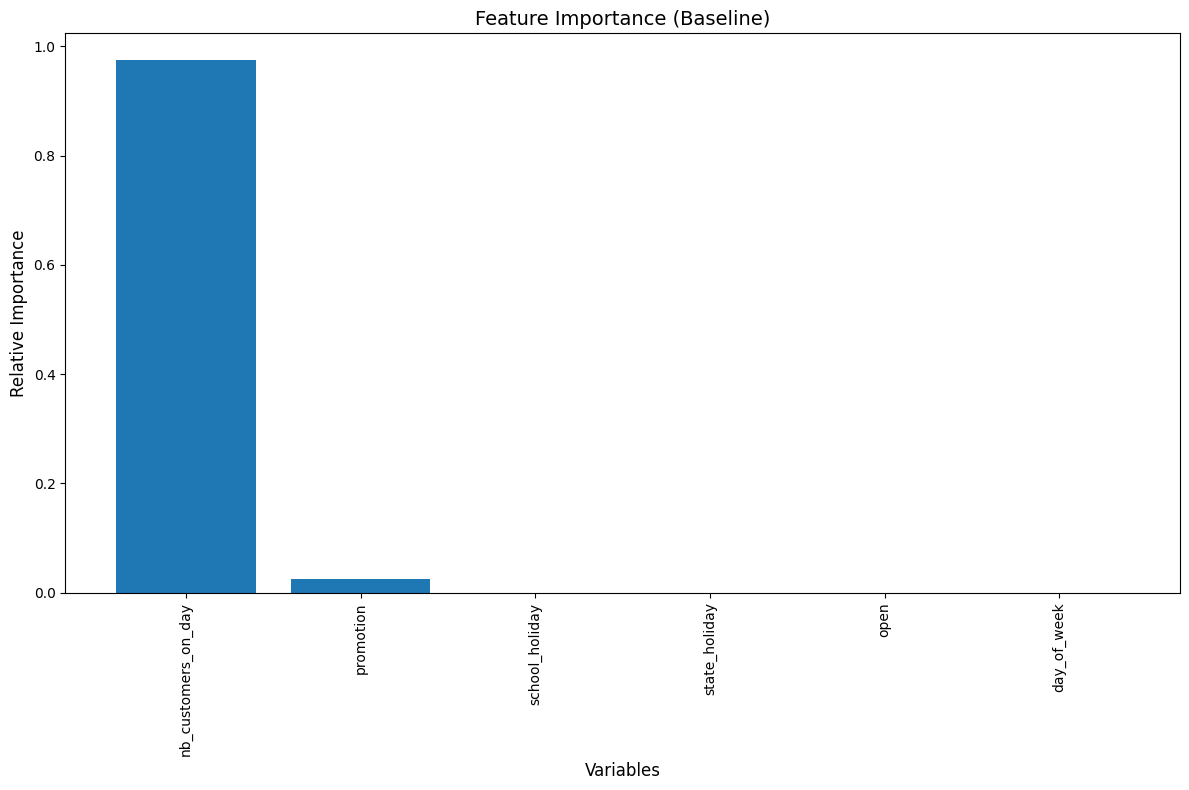

Linear Regression (Baseline) - RMSE: 1620.26, R2 Score: 0.7285


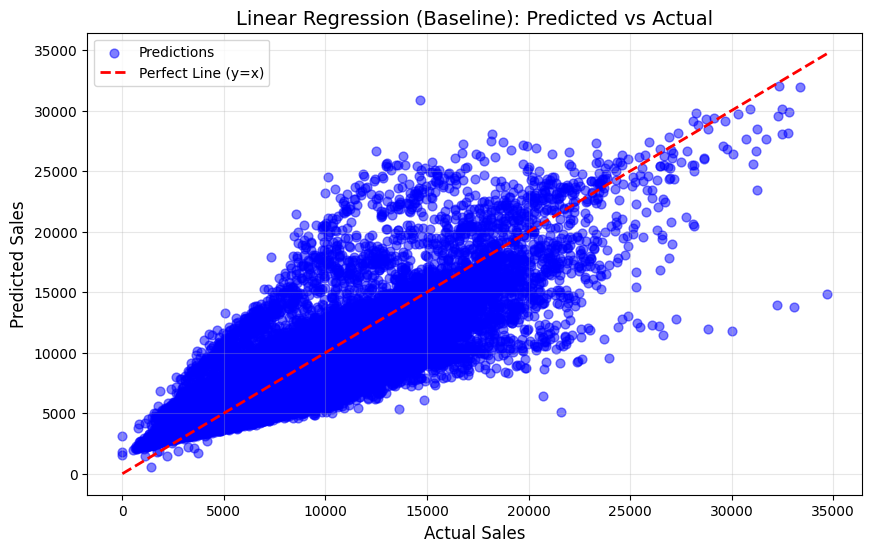

(LinearRegression(),
 array([10036.80908412,  6554.73968561,  3639.08547622, ...,
         4460.06917061,  6876.25480429,  7451.74345263], shape=(106404,)))

In [6]:
# Baseline Dataset features and target
features_baseline = df_filtered.drop(columns=["sales", "store_ID", "date", "Unnamed: 0"], errors="ignore").columns
X_baseline = df_filtered[features_baseline]
y_baseline = df_filtered["sales"]

# Global split for baseline models
X_train, X_test, y_train, y_test = train_test_split(X_baseline, y_baseline, test_size=0.2, random_state=42)

# 1. Linear Regression - Baseline
from sklearn.linear_model import LinearRegression
lr_baseline = LinearRegression()
evaluate_model(lr_baseline, X_train, X_test, y_train, y_test, "Linear Regression (Baseline)")

# 2. Random Forest - Baseline
from sklearn.ensemble import RandomForestRegressor
rf_baseline = RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42, n_jobs=-1)
evaluate_model(rf_baseline, X_train, X_test, y_train, y_test, "Random Forest (Baseline)")

# 3. Decision Tree - Baseline
from sklearn.tree import DecisionTreeRegressor
dt_baseline = DecisionTreeRegressor(max_depth=3, random_state=42)
evaluate_model(dt_baseline, X_train, X_test, y_train, y_test, "Decision Tree (Baseline)")


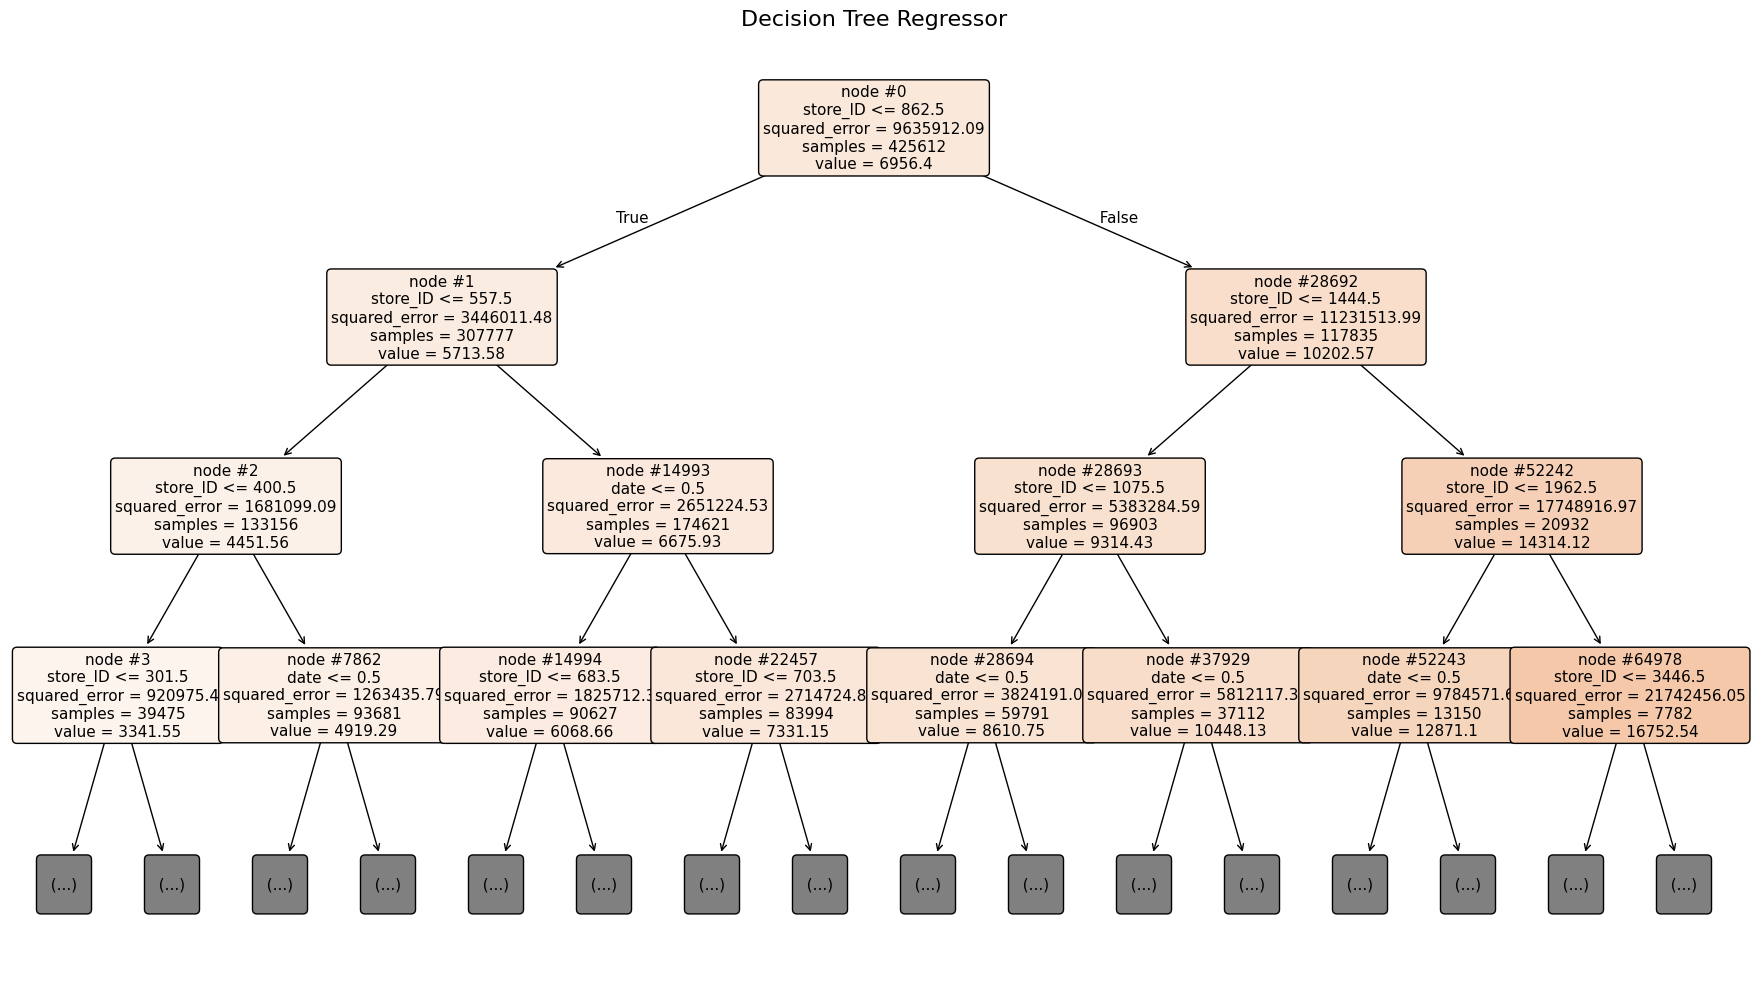

In [8]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 10))          # make it bigger so text is readable
plot_tree(
    dt_model,
    feature_names= df_filtered.columns,      # ← replace with your real feature names: X.columns.tolist()
    filled=True,                      # colors the nodes
    rounded=True,
    fontsize=11,
    precision=2,                      # decimals in split values
    impurity=True,
    max_depth=3,                     # shows MSE / variance reduction
    node_ids=True                     # optional: shows node numbers
)

plt.title("Decision Tree Regressor", fontsize=16)
plt.tight_layout()
plt.show()


# Random Forest Regression

In [9]:
# Define target variable (Sales) and feature matrix
X = df_filtered.drop(columns=['sales', 'store_ID', 'date'])
if 'Unnamed: 0' in X.columns:
    X = X.drop(columns=['Unnamed: 0'])
y = df_filtered['sales']

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, test_size=0.20)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")


X_train shape: (425612, 6)
X_test shape: (106404, 6)


## 🧪 6. Specialized Modeling (Selected Features)
In this section, we train models using only a subset of features ( and ) to observe their individual impact on sales prediction.

Random Forest (Specialized) - RMSE: 1719.34, R2 Score: 0.6943


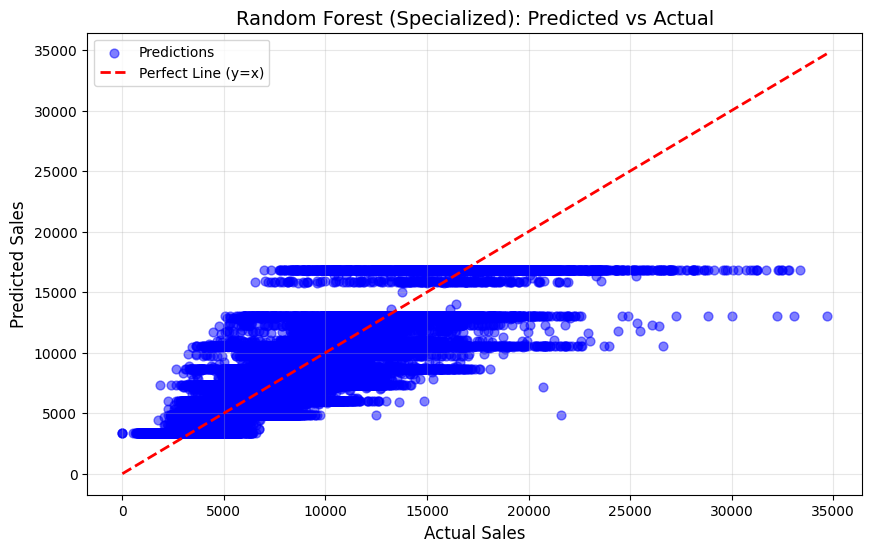

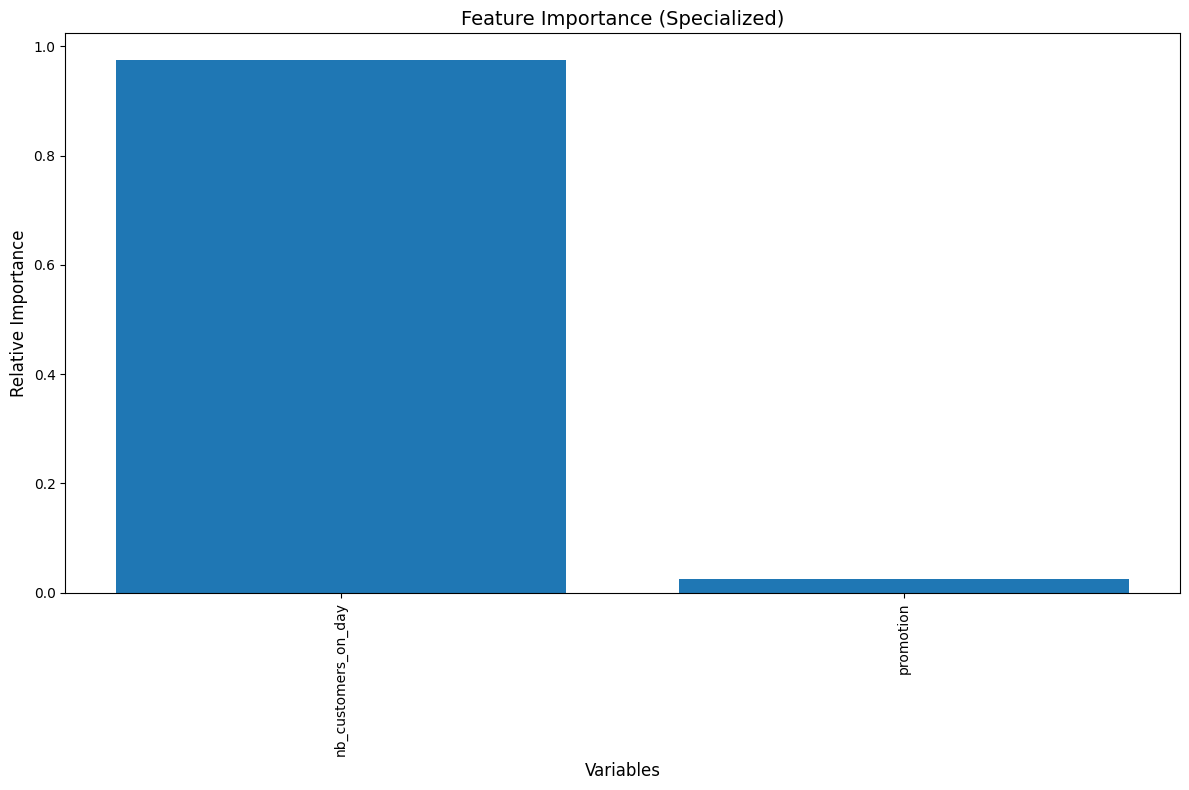

Linear Regression (Specialized) - RMSE: 1626.00, R2 Score: 0.7266


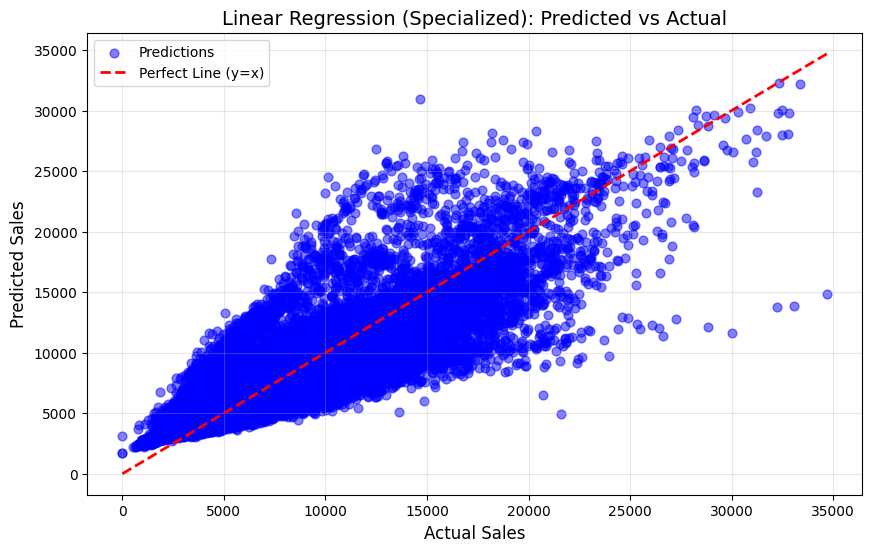

(LinearRegression(),
 array([10124.84794405,  6638.47780358,  3430.06519382, ...,
         4614.45923109,  6960.39002909,  7391.63093497], shape=(106404,)))

In [11]:
# Specialized Dataset features (High impact variables)
features_special = ["nb_customers_on_day", "promotion"]
X_special = df_filtered[features_special]
y_special = df_filtered["sales"]

# Local split for specialized experiment
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_special, y_special, test_size=0.2, random_state=42)

# 1. Linear Regression - Specialized
lr_special = LinearRegression()
evaluate_model(lr_special, X_train_s, X_test_s, y_train_s, y_test_s, "Linear Regression (Specialized)")

# 2. Random Forest - Specialized
rf_special = RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42, n_jobs=-1)
evaluate_model(rf_special, X_train_s, X_test_s, y_train_s, y_test_s, "Random Forest (Specialized)")

# 3. Decision Tree - Specialized
dt_special = DecisionTreeRegressor(max_depth=3, random_state=42)
evaluate_model(dt_special, X_train_s, X_test_s, y_train_s, y_test_s, "Decision Tree (Specialized)")


## 📊 7. Model Comparison
We now consolidate the performance metrics of all models to determine which configuration provides the most reliable predictions.

In [ ]:
# Consolidated result summary for all 6 configurations
perf_data = [
    ["Linear Regression (Baseline)", *get_metrics_summary(lr_baseline, X_test, y_test)],
    ["Random Forest (Baseline)", *get_metrics_summary(rf_baseline, X_test, y_test)],
    ["Decision Tree (Baseline)", *get_metrics_summary(dt_baseline, X_test, y_test)],
    ["Linear Regression (Specialized)", *get_metrics_summary(lr_special, X_test_s, y_test_s)],
    ["Random Forest (Specialized)", *get_metrics_summary(rf_special, X_test_s, y_test_s)],
    ["Decision Tree (Specialized)", *get_metrics_summary(dt_special, X_test_s, y_test_s)]
]

# Display full performance dashboard
comparison_df = pd.DataFrame(perf_data, columns=["Model Configuration", "RMSE", "R2 Score"])
display(comparison_df.sort_values(by="RMSE"))

# Overall comparison visualization
plt.figure(figsize=(12, 6))
sns.barplot(data=comparison_df, x="Model Configuration", y="RMSE", palette="viridis")
plt.title("6-Model Pipeline Comparison (RMSE)", fontsize=14)
plt.ylabel("RMSE (Lower is Better)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()


## 📝 8. Conclusions & Insights
- Summarize key findings from EDA.
- Discuss model accuracy and potential improvements (e.g., trying non-linear models like Random Forest).
- Actionable insights for the business.
